In [ ]:
# Protocol C (rigouros) - Hyperparameter Optimization + Threshold Tuning + Final Evaluation

from google.colab import drive
drive.mount('/content/drive')

import os, time, warnings
import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

PROJECT = '/content/drive/MyDrive/ages-sprint-overrun/pipeline'
IN1 = f'{PROJECT}/01_data_prep'
IN2 = f'{PROJECT}/02_benchmark'
OUT = f'{PROJECT}/03_optimization'
os.makedirs(OUT, exist_ok=True)

FEATURE_COLS = joblib.load(f'{IN1}/feature_cols.pkl')
X_train, X_test, y_train, y_test = joblib.load(f'{IN2}/split_chronological.pkl')
cv_ts = joblib.load(f'{IN2}/cv_scheme.pkl')
df_base = pd.read_csv(f'{IN2}/table_baseline_full.csv')

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'{len(FEATURE_COLS)} features')

TOP_K = 7
modele_selectate = df_base.sort_values('CV AUC', ascending=False)['Model'].head(TOP_K).tolist()
print('Selected for optimization:', modele_selectate)

Mounted at /content/drive
Train: 10830 | Test: 2708
27 features
Selected for optimization: ['Random Forest', 'Gradient Boosting', 'XGBoost', 'AdaBoost', 'MLP', 'Logistic Regression', 'Decision Tree']


In [ ]:
# RandomizedSearchCV - 30 iterations

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

def pipe(clf, scale=False):
    steps = [('smote', SMOTE(random_state=RANDOM_STATE))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

N_ITER = 30

spatii = {
    'Random Forest': (pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)), {
        'clf__n_estimators': randint(100, 500), 'clf__max_depth': randint(4, 20),
        'clf__min_samples_split': randint(2, 20), 'clf__min_samples_leaf': randint(1, 10),
        'clf__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8],
    }),
    'Gradient Boosting': (pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)), {
        'clf__n_estimators': randint(100, 500), 'clf__max_depth': randint(2, 6),
        'clf__learning_rate': loguniform(0.01, 0.2), 'clf__subsample': uniform(0.6, 0.4),
        'clf__min_samples_leaf': randint(1, 20),
    }),
    'XGBoost': (pipe(XGBClassifier(random_state=RANDOM_STATE, n_jobs=1,
                     eval_metric='logloss')), {
        'clf__n_estimators': randint(100, 500), 'clf__max_depth': randint(3, 10),
        'clf__learning_rate': loguniform(0.01, 0.3), 'clf__subsample': uniform(0.5, 0.5),
        'clf__colsample_bytree': uniform(0.5, 0.5), 'clf__min_child_weight': randint(1, 10),
        'clf__gamma': uniform(0, 5),
    }),
    'MLP': (pipe(MLPClassifier(activation='relu', max_iter=300, early_stopping=True,
                 n_iter_no_change=10, random_state=RANDOM_STATE), scale=True), {
        'clf__hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
        'clf__alpha': loguniform(1e-5, 1e-1), 'clf__learning_rate_init': loguniform(1e-4, 1e-1),
        'clf__batch_size': [64, 128, 200],
    }),
    'Logistic Regression': (pipe(LogisticRegression(max_iter=2000,
                            random_state=RANDOM_STATE), scale=True), {
        'clf__C': loguniform(1e-3, 1e2), 'clf__penalty': ['l2'],
    }),
    'Decision Tree': (pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)), {
        'clf__max_depth': randint(3, 20), 'clf__min_samples_split': randint(2, 30),
        'clf__min_samples_leaf': randint(1, 20),
    }),
    'AdaBoost': (pipe(AdaBoostClassifier(random_state=RANDOM_STATE)), {
        'clf__n_estimators': randint(50, 400), 'clf__learning_rate': loguniform(0.01, 1.0),
    }),
}

modele_opt = {}
best_params_rows = []

for nume in modele_selectate:
    base_pipe, grid = spatii[nume]
    print(f'\n RandomizedSearchCV — {nume} ...')
    t0 = time.time()
    search = RandomizedSearchCV(base_pipe, param_distributions=grid, n_iter=N_ITER,
                                cv=cv_ts, scoring='roc_auc', random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    dt = time.time() - t0

    modele_opt[nume] = search.best_estimator_
    print(f'  Best CV AUC = {search.best_score_:.4f}   ({dt/60:.1f} min)')

    row = {'Model': nume, 'Best CV AUC': round(search.best_score_, 4),
           'Search time (min)': round(dt/60, 1)}
    row.update({k.replace('clf__', ''): v for k, v in search.best_params_.items()})
    best_params_rows.append(row)

df_params = pd.DataFrame(best_params_rows)
df_params.to_csv(f'{OUT}/table_optimized_hyperparameters.csv', index=False)
joblib.dump(modele_opt, f'{OUT}/modele_optimizate.pkl')
df_params


 RandomizedSearchCV — Random Forest ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6426   (21.8 min)

 RandomizedSearchCV — Gradient Boosting ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6441   (23.2 min)

 RandomizedSearchCV — XGBoost ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6425   (3.2 min)

 RandomizedSearchCV — AdaBoost ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6368   (10.3 min)

 RandomizedSearchCV — MLP ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6236   (9.6 min)

 RandomizedSearchCV — Logistic Regression ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.6153   (0.5 min)

 RandomizedSearchCV — Decision Tree ...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
  Best CV AUC = 0.5978   (0.6 min)


,Model,Best CV AUC,Search time (min),max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,learning_rate,subsample,colsample_bytree,gamma,min_child_weight,alpha,batch_size,hidden_layer_sizes,learning_rate_init,C,penalty
0,Random Forest,0.6426,21.8,7.0,sqrt,2.0,10.0,445.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gradient Boosting,0.6441,23.2,2.0,NaN,4.0,NaN,321.0,0.041540,0.655733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost,0.6425,3.2,4.0,NaN,NaN,NaN,319.0,0.024778,0.525739,0.574043,4.988702,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,AdaBoost,0.6368,10.3,NaN,NaN,NaN,NaN,184.0,0.524663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MLP,0.6236,9.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000088,128.0,"(100, 50)",0.000132,NaN,NaN
5,Logistic Regression,0.6153,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001267,l2
6,Decision Tree,0.5978,0.6,5.0,NaN,5.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# REINCARCARE FISIER!!!

import joblib
modele_opt = joblib.load(f'{OUT}/modele_optimizate.pkl')
print(list(modele_opt.keys()))

['Random Forest', 'Gradient Boosting', 'XGBoost', 'AdaBoost', 'MLP', 'Logistic Regression', 'Decision Tree']


In [ ]:
# Threshold selection — OOF on train only

from sklearn.metrics import precision_recall_curve, matthews_corrcoef
from sklearn.base import clone

def oof_proba(model, X, y, cv):
    proba = np.full(len(y), np.nan)
    for tr, va in cv.split(X):
        m = clone(model)
        m.fit(X.iloc[tr], y.iloc[tr])
        proba[va] = m.predict_proba(X.iloc[va])[:, 1]
    return proba

def prag_optim(model, X, y, cv, nume=''):
    proba = oof_proba(model, X, y, cv)
    ok = ~np.isnan(proba)
    p, r, thr = precision_recall_curve(y[ok], proba[ok])
    f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-10)
    i = int(np.argmax(f1))
    print(f'{nume:22s} threshold={thr[i]:.4f}  (OOF: P={p[i]:.3f} R={r[i]:.3f} F1={f1[i]:.3f})')
    return float(thr[i])

thresholds = {}
for nume, model in modele_opt.items():
    thresholds[nume] = prag_optim(model, X_train, y_train, cv_ts, nume)

joblib.dump(thresholds, f'{OUT}/thresholds.pkl')
pd.DataFrame([{'Model': k, 'Decision threshold': round(v, 4)}
              for k, v in thresholds.items()]).to_csv(f'{OUT}/table_thresholds.csv', index=False)

Random Forest          threshold=0.4547  (OOF: P=0.471 R=0.848 F1=0.605)
Gradient Boosting      threshold=0.3280  (OOF: P=0.447 R=0.912 F1=0.600)
XGBoost                threshold=0.3671  (OOF: P=0.457 R=0.891 F1=0.604)
AdaBoost               threshold=0.4517  (OOF: P=0.454 R=0.878 F1=0.599)
MLP                    threshold=0.3659  (OOF: P=0.456 R=0.853 F1=0.594)
Logistic Regression    threshold=0.4172  (OOF: P=0.441 R=0.878 F1=0.587)
Decision Tree          threshold=0.2917  (OOF: P=0.433 R=0.926 F1=0.591)


In [ ]:
# Final evaluation

from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix)

rows = []
predictii_finale = {}

for nume, model in modele_opt.items():
    thr = thresholds[nume]
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= thr).astype(int)
    predictii_finale[nume] = {'y_proba': proba, 'y_pred': pred, 'threshold': thr}

    rows.append({
        'Model': nume,
        'Threshold': round(thr, 3),
        'Test AUC': round(roc_auc_score(y_test, proba), 3),
        'Precision (Exceeds)': round(precision_score(y_test, pred, pos_label=1, zero_division=0), 3),
        'Recall (Exceeds)': round(recall_score(y_test, pred, pos_label=1), 3),
        'F1 (Exceeds)': round(f1_score(y_test, pred, pos_label=1), 3),
        'MCC': round(matthews_corrcoef(y_test, pred), 3),
        'Accuracy (weighted)': round(accuracy_score(y_test, pred), 3),
        'F1 (weighted)': round(f1_score(y_test, pred, average='weighted'), 3),
    })

df_final = pd.DataFrame(rows).sort_values('MCC', ascending=False).reset_index(drop=True)
df_final.to_csv(f'{OUT}/table_final_test_results.csv', index=False)
joblib.dump(predictii_finale, f'{OUT}/predictii_finale.pkl')

MODEL_FINAL = df_final.loc[0, 'Model']
RUNNER_UP   = df_final.loc[1, 'Model']
joblib.dump(MODEL_FINAL, f'{OUT}/model_final_name.pkl')
joblib.dump(RUNNER_UP, f'{OUT}/runner_up_name.pkl')

print(f'Final model: {MODEL_FINAL}   |   Runner-up: {RUNNER_UP}')
df_final

Final model: Random Forest   |   Runner-up: XGBoost


,Model,Threshold,Test AUC,Precision (Exceeds),Recall (Exceeds),F1 (Exceeds),MCC,Accuracy (weighted),F1 (weighted)
0,Random Forest,0.455,0.693,0.466,0.658,0.545,0.274,0.641,0.652
1,XGBoost,0.367,0.696,0.434,0.764,0.553,0.265,0.596,0.606
2,Gradient Boosting,0.328,0.699,0.414,0.828,0.552,0.254,0.559,0.562
3,AdaBoost,0.452,0.692,0.446,0.681,0.539,0.253,0.619,0.631
4,MLP,0.366,0.638,0.409,0.703,0.517,0.197,0.570,0.581
5,Decision Tree,0.292,0.648,0.379,0.884,0.530,0.197,0.487,0.467
6,Logistic Regression,0.417,0.625,0.387,0.676,0.492,0.147,0.544,0.555


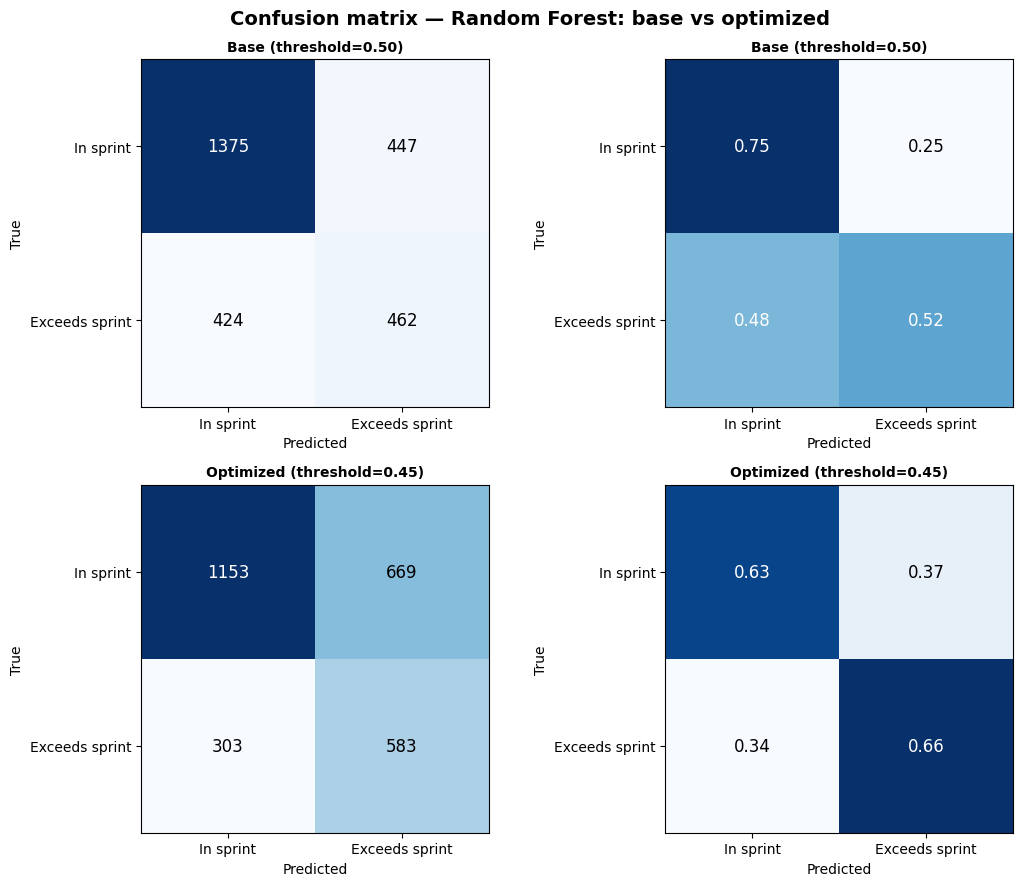

In [ ]:
# Confusion matrix — final model, base vs. optimized

import matplotlib.pyplot as plt

rezultate_base = joblib.load(f'{IN2}/rezultate_base.pkl')
y_pred_base_final = rezultate_base[MODEL_FINAL]['y_pred']
y_pred_opt_final  = predictii_finale[MODEL_FINAL]['y_pred']

labels = ['In sprint', 'Exceeds sprint']
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle(f'Confusion matrix — {MODEL_FINAL}: base vs optimized', fontsize=14, fontweight='bold')

configs = [(y_pred_base_final, 'threshold=0.50', 'Base'),
           (y_pred_opt_final, f'threshold={thresholds[MODEL_FINAL]:.2f}', 'Optimized')]

for r, (pred, thr_lbl, lbl) in enumerate(configs):
    cm  = confusion_matrix(y_test, pred)
    cmn = confusion_matrix(y_test, pred, normalize='true')
    for col, (mat, fmt) in enumerate([(cm, 'd'), (cmn, '.2f')]):
        ax = axes[r, col]
        ax.imshow(mat, cmap='Blues')
        for i in range(2):
            for j in range(2):
                v = mat[i, j]
                ax.text(j, i, format(v, fmt), ha='center', va='center',
                        color='white' if v > mat.max()*0.6 else 'black', fontsize=12)
        ax.set_xticks([0,1]); ax.set_xticklabels(labels)
        ax.set_yticks([0,1]); ax.set_yticklabels(labels)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{lbl} ({thr_lbl})', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT}/fig_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Bootstrap confidence intervals — final model

def bootstrap_ci(y_true, y_pred, y_proba, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    yt = np.asarray(y_true); yp = np.asarray(y_pred); pr = np.asarray(y_proba)
    n = len(yt)
    acc = {'Test AUC': [], 'Precision': [], 'Recall': [], 'F1-score': [], 'MCC': []}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(yt[idx])) < 2:
            continue
        acc['Test AUC'].append(roc_auc_score(yt[idx], pr[idx]))
        acc['Precision'].append(precision_score(yt[idx], yp[idx], pos_label=1, zero_division=0))
        acc['Recall'].append(recall_score(yt[idx], yp[idx], pos_label=1))
        acc['F1-score'].append(f1_score(yt[idx], yp[idx], pos_label=1))
        acc['MCC'].append(matthews_corrcoef(yt[idx], yp[idx]))
    out = []
    for k, v in acc.items():
        v = np.array(v)
        out.append({'Metric': k, 'Estimate': round(v.mean(), 3),
                    'CI lower (2.5%)': round(np.percentile(v, 2.5), 3),
                    'CI upper (97.5%)': round(np.percentile(v, 97.5), 3)})
    return pd.DataFrame(out)

pf = predictii_finale[MODEL_FINAL]
df_ci = bootstrap_ci(y_test, pf['y_pred'], pf['y_proba'])
df_ci.to_csv(f'{OUT}/table_bootstrap_ci.csv', index=False)
print(f'Bootstrap CI — {MODEL_FINAL}')
df_ci

Bootstrap CI — Random Forest


,Metric,Estimate,CI lower (2.5%),CI upper (97.5%)
0,Test AUC,0.693,0.673,0.714
1,Precision,0.466,0.438,0.494
2,Recall,0.658,0.628,0.690
3,F1-score,0.545,0.520,0.571
4,MCC,0.274,0.239,0.311


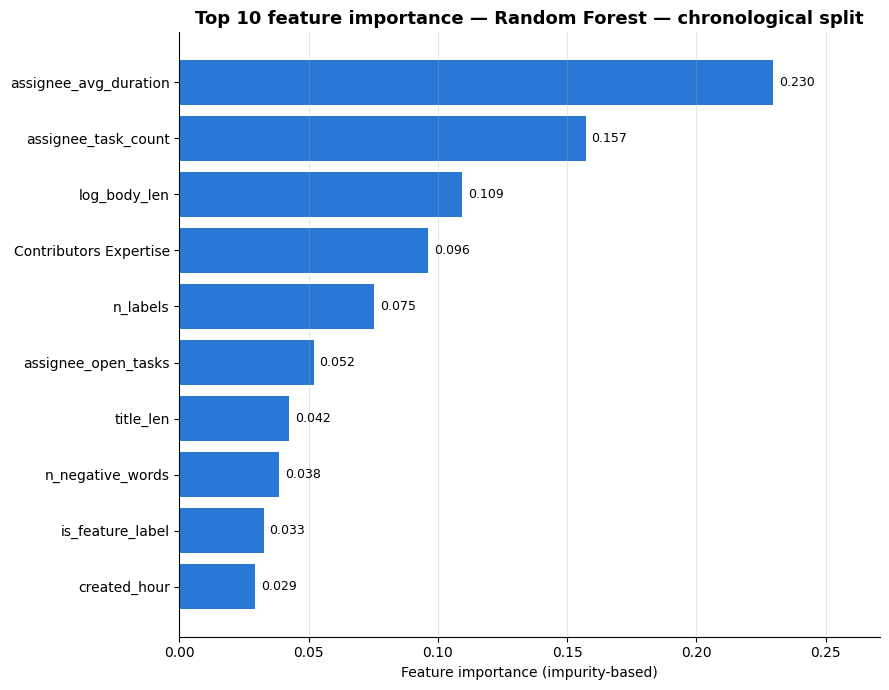

,0
assignee_avg_duration,0.229667
assignee_task_count,0.157149
log_body_len,0.109444
Contributors Expertise,0.096174
n_labels,0.075399
assignee_open_tasks,0.051882
title_len,0.042385
n_negative_words,0.038471
is_feature_label,0.032569
created_hour,0.029126


In [ ]:
# Feature importance - top 10

import joblib
import matplotlib.pyplot as plt

modele_opt_models = joblib.load(f'{OUT}/modele_optimizate.pkl')

clf = modele_opt_models[MODEL_FINAL].named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
    xlabel = 'Feature importance (impurity-based)'
else:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(modele_opt_models[MODEL_FINAL], X_test, y_test, n_repeats=10,
                                random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=FEATURE_COLS)
    xlabel = 'Permutation importance (ROC-AUC drop)'

imp = imp.sort_values(ascending=False)
imp.to_csv(f'{OUT}/table_feature_importance.csv')

top10 = imp.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top10.index, top10.values, color='#2a78d6')
for b, v in zip(bars, top10.values):
    ax.text(b.get_width() + top10.max()*0.01, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel(xlabel)
ax.set_title(f'Top 10 feature importance — {MODEL_FINAL} — chronological split', fontweight='bold', fontsize=13)
ax.set_xlim(0, top10.max()*1.18)
ax.grid(axis='x', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT}/fig_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
imp.head(10)

## Save final models

In [ ]:
# Save final models

joblib.dump(modele_opt[MODEL_FINAL], f'{OUT}/final_model.pkl')
print(f'Saved to {OUT}')

Saved to /content/drive/MyDrive/ages-sprint-overrun/pipeline/03_optimization
